# Análisis de PM2.5 en la Región Metropolitana

Este proyecto analiza datos de calidad del aire (PM2.5, PM10 y otros contaminantes) en distintas comunas de Santiago.

## Objetivos
- Integrar datos de múltiples archivos CSV en un único DataFrame.
- Normalizar y limpiar las columnas para un análisis consistente.
- Calcular promedios de contaminantes por comuna.
- Visualizar comparativamente los resultados mediante gráficos.

## Metodología
1. **Integración de datos**: unión de todos los CSV en un DataFrame.
2. **Limpieza y normalización**: conversión de nombres de columnas y valores numéricos.
3. **Análisis**: cálculo de promedios por comuna.
4. **Visualización**: gráficos comparativos de contaminantes por comuna.


### 1- Importar librerías

In [20]:
import pandas as pd   # Manejo de datos en tablas (DataFrames)
import matplotlib.pyplot as plt   # Crear gráficos y visualizaciones
import glob   # Buscar archivos en la carpeta usando patrones


### 2- Verificar la carpeta actual del Notebook

In [21]:
import os 
print(os.getcwd())

/home/5c4bc6af-59e4-4b86-8252-acdc575686b6/CIENCIA DE DATOS/Analisis_PM25_RM


### 3- Cargar todos los archivos CSV

In [22]:
files = glob.glob("PM25_*.csv") # Busca dentro de la carpeta 'data' 
print(files) # Muestra la lista de archivos encontrados


['PM25_parque_ohiggins.csv', 'PM25_la_florida.csv', 'PM25_puente_alto.csv', 'PM25_cerrillos.csv', 'PM25_cerro_navia.csv', 'PM25_pudahuel.csv', 'PM25_quilicura.csv']


### 4-Concadenación archivos CSV

In [23]:
import os 
print(os.listdir())

['PM25_parque_ohiggins.csv', 'PM25_la_florida.csv', 'PM25_puente_alto.csv', 'PM25_cerrillos.csv', '.ipynb_checkpoints', 'Analisis_PM25_RM.ipynb', 'PM25_cerro_navia.csv', 'PM25_pudahuel.csv', 'PM25_quilicura.csv']


In [24]:
import pandas as pd
import os

files = [ 
    "PM25_cerrillos.csv", 
    "PM25_cerro_navia.csv",
    "PM25_la_florida.csv", 
    "PM25_parque_ohiggins.csv", 
    "PM25_pudahuel.csv", 
    "PM25_puente_alto.csv", 
    "PM25_quilicura.csv" 
]

dfs = [] 
for f in files: 
    # Leer cada archivo CSV 
    df = pd.read_csv(f) 
    df.columns = df.columns.str.strip().str.lower()

    # Extraer correctamente la comuna desde el nombre del archivo 
    df['comuna'] = f.replace("PM25_", "").replace(".csv", "")

    # Convertir columnas numéricas 
    for col in ["pm25","pm10","o3","no2","so2","co"]: 
        if col in df.columns: 
            df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace("", None), errors="coerce")

    # Guardar el DataFrame en la lista 
    dfs.append(df)

    # Unir todos los DataFrames en uno solo 
    data = pd.concat(dfs)
    # Convertir la columna 'date' a formato fecha 
    data['date'] = pd.to_datetime(data['date'], errors='coerce')

    # Ver primeras filas para verificar 
    print(data.head())


        date   pm25   pm10     comuna
0 2025-06-02  142.0   95.0  cerrillos
1 2025-06-03  147.0  118.0  cerrillos
2 2025-06-04  163.0   98.0  cerrillos
3 2025-06-05  160.0  108.0  cerrillos
4 2025-06-06  164.0   86.0  cerrillos
        date   pm25   pm10     comuna  o3  no2  so2  co
0 2025-06-02  142.0   95.0  cerrillos NaN  NaN  NaN NaN
1 2025-06-03  147.0  118.0  cerrillos NaN  NaN  NaN NaN
2 2025-06-04  163.0   98.0  cerrillos NaN  NaN  NaN NaN
3 2025-06-05  160.0  108.0  cerrillos NaN  NaN  NaN NaN
4 2025-06-06  164.0   86.0  cerrillos NaN  NaN  NaN NaN
        date   pm25   pm10     comuna  o3  no2  so2  co
0 2025-06-02  142.0   95.0  cerrillos NaN  NaN  NaN NaN
1 2025-06-03  147.0  118.0  cerrillos NaN  NaN  NaN NaN
2 2025-06-04  163.0   98.0  cerrillos NaN  NaN  NaN NaN
3 2025-06-05  160.0  108.0  cerrillos NaN  NaN  NaN NaN
4 2025-06-06  164.0   86.0  cerrillos NaN  NaN  NaN NaN
        date   pm25   pm10     comuna  o3  no2  so2  co
0 2025-06-02  142.0   95.0  cerrillos NaN  N

### 5- Limpiar nombres de columnas

In [25]:
data.columns = data.columns.str.strip().str.lower()


### 6-convertir las columnas relevantes a números

In [26]:
# Forzar conversión de todas las columnas numéricas
for col in ["pm25","pm10","o3","no2","so2","co"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")


## Análisis y visualización

### 7.-Promedio por comuna

In [27]:
promedios = data.groupby("comuna")[["pm25","pm10","o3","no2","so2","co"]].mean()
print(promedios)



                      pm25       pm10         o3        no2        so2  \
comuna                                                                   
cerrillos        73.550245  54.332925        NaN        NaN        NaN   
cerro_navia      82.097371  55.802670  23.767654  19.683809  58.428571   
la_florida       75.615197  54.723260  25.750000  18.599410   3.499866   
parque_ohiggins  75.347625  57.576430  25.622968  21.614026   2.771300   
pudahuel         77.589294  55.484318  22.977323  19.525864  63.200000   
puente_alto      72.314251  55.381748  29.177743  17.625367   4.424918   
quilicura        75.985606  55.156948  22.960022  17.129800   3.935484   

                        co  
comuna                      
cerrillos              NaN  
cerro_navia      10.708229  
la_florida       10.272392  
parque_ohiggins  10.157701  
pudahuel          9.327107  
puente_alto       7.200650  
quilicura         8.183559  


### Graficar los promedios

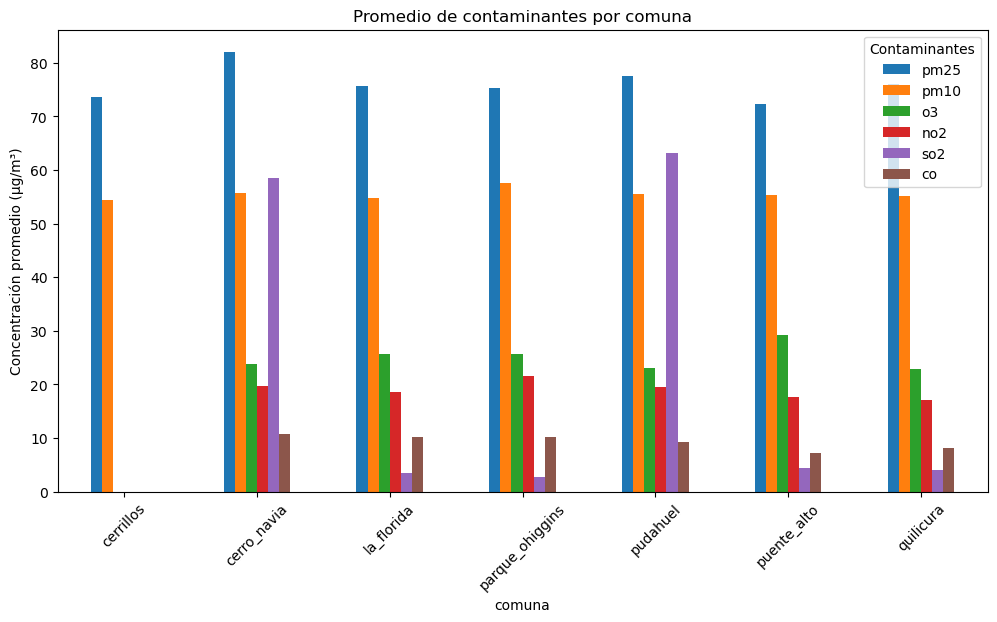

In [28]:
import matplotlib.pyplot as plt 
# Gráfico de barras por comuna 
promedios.plot(kind="bar", figsize=(12,6)) 
plt.title("Promedio de contaminantes por comuna") 
plt.ylabel("Concentración promedio (µg/m³)") 
plt.xticks(rotation=45) 
plt.legend(title="Contaminantes") 
plt.show()

### Visuzalización cada contaminante por separado

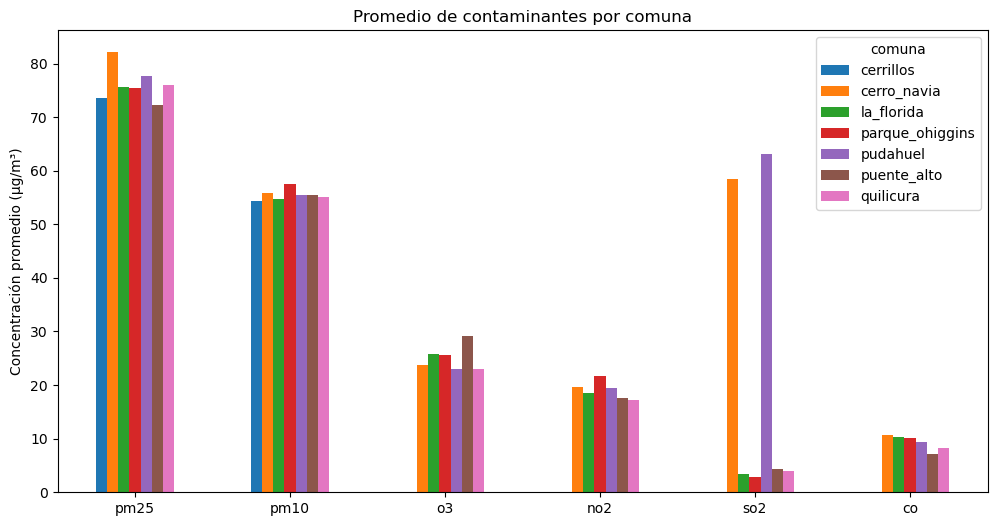

In [29]:
promedios.T.plot(kind="bar", figsize=(12,6)) 
plt.title("Promedio de contaminantes por comuna") 
plt.ylabel("Concentración promedio (µg/m³)") 
plt.xticks(rotation=0)
plt.show()

### contaminantes que faltan en cada comuna

In [31]:
print(promedios.isna())

                  pm25   pm10     o3    no2    so2     co
comuna                                                   
cerrillos        False  False   True   True   True   True
cerro_navia      False  False  False  False  False  False
la_florida       False  False  False  False  False  False
parque_ohiggins  False  False  False  False  False  False
pudahuel         False  False  False  False  False  False
puente_alto      False  False  False  False  False  False
quilicura        False  False  False  False  False  False


### Ranking de comunas por contaminante  PM25 

In [32]:
print(promedios['pm25'].sort_values(ascending=False))


comuna
cerro_navia        82.097371
pudahuel           77.589294
quilicura          75.985606
la_florida         75.615197
parque_ohiggins    75.347625
cerrillos          73.550245
puente_alto        72.314251
Name: pm25, dtype: float64


In [33]:
# Conclusiones automáticas
max_pm25 = promedios['pm25'].idxmax()
max_pm25_val = promedios['pm25'].max()

min_pm25 = promedios['pm25'].idxmin()
min_pm25_val = promedios['pm25'].min()

print(f"La comuna con mayor concentración promedio de PM2.5 es {max_pm25} ({max_pm25_val:.2f} µg/m³).")
print(f"La comuna con menor concentración promedio de PM2.5 es {min_pm25} ({min_pm25_val:.2f} µg/m³).")

# Si quieres ver también el ranking de otro contaminante, por ejemplo NO2:
max_no2 = promedios['no2'].idxmax()
print(f"La comuna con mayor concentración promedio de NO2 es {max_no2}.")


La comuna con mayor concentración promedio de PM2.5 es cerro_navia (82.10 µg/m³).
La comuna con menor concentración promedio de PM2.5 es puente_alto (72.31 µg/m³).
La comuna con mayor concentración promedio de NO2 es parque_ohiggins.


In [35]:
conclusiones = f""" 
## Conclusiones 
- La comuna con mayor concentración promedio de **PM2.5** es **{max_pm25}** ({max_pm25_val:.2f} µg/m³). 
- La comuna con menor concentración promedio de **PM2.5** es **{min_pm25}** ({min_pm25_val:.2f} µg/m³). 
- La comuna con mayor concentración promedio de **NO₂** es **{max_no2}**. """ 
from IPython.display import Markdown display(Markdown(conclusiones))

 
## Conclusiones 
- La comuna con mayor concentración promedio de **PM2.5** es **cerro_navia** (82.10 µg/m³). 
- La comuna con menor concentración promedio de **PM2.5** es **puente_alto** (72.31 µg/m³). 
- La comuna con mayor concentración promedio de **NO₂** es **parque_ohiggins**. 

# Informe de Calidad del Aire - Región Metropolitana

## Resultados principales
- La comuna con mayor concentración promedio de **PM2.5** es **Cerro Navia** (82.10 µg/m³).
- La comuna con menor concentración promedio de **PM2.5** es **Puente Alto** (72.31 µg/m³).
- La comuna con mayor concentración promedio de **NO₂** es **Parque O’Higgins**.

## Observaciones
- Se detectaron valores faltantes en algunas comunas (ej. Cerrillos carece de datos para O₃, NO₂, SO₂ y CO).
- La mayoría de las comunas presentan niveles de PM2.5 y PM10 relativamente similares, con diferencias más marcadas en gases como NO₂ y SO₂.
- Cerro Navia destaca como la comuna más crítica en PM2.5, mientras Puente Alto muestra los valores más bajos.


# Informe de Calidad del Aire - Región Metropolitana

## Resultados principales
- La comuna con mayor concentración promedio de **PM2.5** es **Cerro Navia** (82.10 µg/m³).
- La comuna con menor concentración promedio de **PM2.5** es **Puente Alto** (72.31 µg/m³).
- La comuna con mayor concentración promedio de **NO₂** es **Parque O’Higgins**.

## Observaciones
- Se detectaron valores faltantes en algunas comunas (ej. Cerrillos carece de datos para O₃, NO₂, SO₂ y CO).
- La mayoría de las comunas presentan niveles de PM2.5 y PM10 relativamente similares.
- Cerro Navia destaca como la comuna más crítica en PM2.5, mientras Puente Alto muestra los valores más bajos.

## Qué sí se puede hacer
- **Modelos de simulación**: proyectar escenarios de reducción de emisiones.
- **Metas graduales**: planes con horizontes de 10 años y evaluaciones periódicas.
- **Indicadores de éxito**: reducción de días críticos, cumplimiento de normas OMS.

## Ejemplo real
En Santiago existen **Planes de Descontaminación Atmosférica (PDA)**.  
Estos han reducido PM10, pero el PM2.5 sigue siendo difícil de controlar.  
Los plazos suelen ser de una década o más para ver mejoras sostenidas.

## Conclusión
El análisis de datos muestra las comunas más afectadas, y la revisión de factores externos evidencia que la descontaminación requiere políticas públicas sostenidas, cumplimiento estricto y horizontes de largo plazo.

